In [36]:
# Code imports
from lib.opt_types import *
from lib.utils import *
import numpy as np

# Image inpainting with proximal methods - 30 points

Image in-painting consists of reconstructing the missing parts of an image from a given incomplete image.

By exploiting some prior knowledge on the image, it is possible to in-paint images that have a large portion of their pixels missing. In this part of the homework, we are going to study different methods to achieve this goal.

We consider a subsampled image $\mathbf{b} = \mathbf{P}_{\Omega} \mathbf{x}$, where $\mathbf{P}_{\Omega} \in \mathbb{R}^{n \times p}$ is an operator that selects only few, $n \ll p := m^2$, pixels from the vectorized image $\mathbf{x} \in \mathbb{R}^p$. Our goal is to reconstruct the original image $\mathbf{x}$.

### Prior knowledge

Image inpainting is impossible without having some prior knowledge on the structure of the true image $\mathbf{x}$. 

We will explore and compare the following prior assumptions we can make on the true image: 
>  **Assumption**: There exists a orthonormal basis $\mathbf{W} \in \mathbb{R}^{p\times p}$ such that $\mathbf{x}$ can be sparsely represented in that basis, i.e, $\mathbf{W} \mathbf{x}$ is a vector with few non-zero coefficients. Said more formally, this assumption states that there exists $\mathbf{\alpha} \in \mathbb{R}^p$ with small $\ell_1$ norm such that $\mathbf{x} = \mathbf{W}^\top\alpha$. We assume that this basis is known and corresponds to the _wavelet basis_. Under this assumption, the reconstruction problem corresponds to solving the following optimization problem:
$$
    \min_{\mathbf{\alpha} \in \mathbb{R}^{p}} \underbrace{ \frac{1}{2}\|\mathbf{b} - \mathbf{P}_{\Omega} \mathbf{W}^T\mathbf{\alpha} \|_2^2}_{f_{\ell_1}(\mathbf{\alpha})} + \underbrace{\lambda_{\ell_1} \|\mathbf{\alpha}\|_1}_{g_{\ell_1}(\mathbf{\alpha})},
$$
where $\lambda_{\ell_1}$ is a coefficient we will need to choose.



# PART 1: Optimizing with an $\ell_1$ norm regularization

The optimization problem we are looking to solve have an objective function of the form:
$$
	 f(\mathbf{x}) + g(\mathbf{x}).
$$

These types of objectives are referred to as _composite objectives_ where one term, $f$, is smooth and differentiable and the other term $g$ is non-differentiable.

---

## Code structure:

Recall that we have been working with the `Function` type so far. We will augment this type to represent functions that are not differentiable:

- Given a `Function` `g` you can obtain a subgradient at a point `x` by calling `g.subgrad(x)`.

Moreover, since we are dealing with _composite_ problems with a an objective function that can be written `f + lambda*g`, we define the `CompositeFunction` type defined as
```python
@dataclass
class CompositeFunction:
    f: Function
    g: Function
```

The iterative schemes you will implement will receive a composite function that they can unpack as follows:

```python
def state_update(composite_function, state):
    f, g = composite_function

```

#### Question 1: (5 point)

A first approach to solve a non-smooth optimization problem can be to turn to subgradients. Review slide 42-44 of Lecture 6, and implement `SubG` with $\alpha_k = \frac{0.1}{\sqrt{k}}$.

In [37]:
@dataclass
class SubG_state(OptState):
    x_k: Vector
    k: int

In [38]:
def SubG_update(composite_function, state):
    f, g, = composite_function
    x_k, k = state

    alpha_k = 0.1 / np.sqrt(k)
    x_next = x_k - alpha_k * (f.grad(x_k) + g.subgrad(x_k))
    
    return SubG_state(x_k=x_next, k=k+1)


def SubG_initialize(composite_function, x_zero):  # not using composite_function here ?
    return SubG_state(x_k=x_zero, k=1)

In [39]:
SubG = OptAlgorithm(name="SubG", init_state=SubG_initialize, state_update=SubG_update)

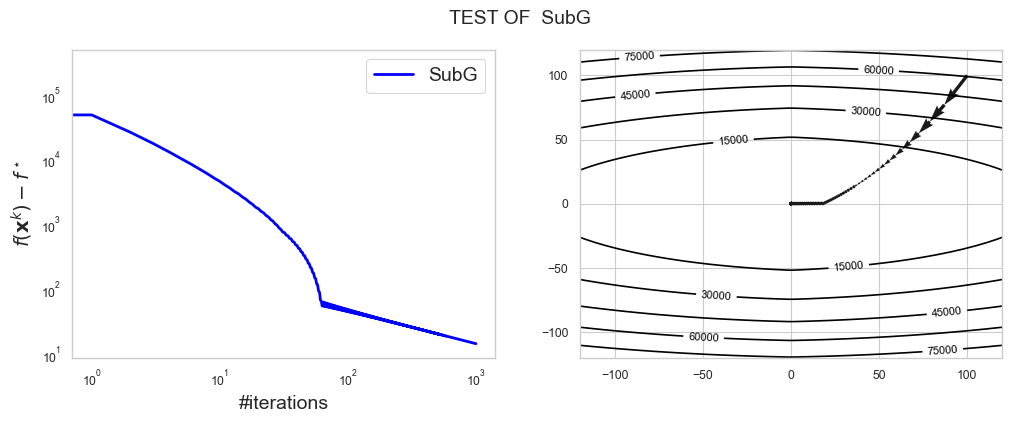

In [40]:
test_composite(SubG)


---

Another, more efficient approach, as we saw in Lecture 7, is to minimize such a function by using proximal gradient algorithms, provided that $g$ is _proximable_ (i.e., its proximal operator is efficient to evaluate). We recall the proximal operator of $g$ as the solution to the following convex problem:
$$
\mathrm{prox}_g(\mathbf{z}) := \mathrm{arg}\min_{\mathbf{y}\in\mathbb{R}^d}\{ g(\mathbf{y}) + \frac{1}{2}\Vert\mathbf{y} - \mathbf{z}\Vert_2^2\}.
$$

#### Question 2 (2 points)

Given $g_{\ell_1}: \mathbb{R}^p \rightarrow \mathbb{R}, \; g_{\ell_1}(\mathbf{x}) :=  \|\mathbf{x}\|_1$,  show that its proximal function can be written as
    $$
    \mathrm{prox}_{\gamma g_{\ell_1}}(\mathbf{z}) = \max(|\mathbf{z}|-\gamma,0) \circ \mathrm{sign}(\mathbf{z}), \; \text{for any }\mathbf{z} \in \mathbb{R}^p,\; \gamma \in \mathbb{R}_+
    $$
			where the operators $\max$, $\mathrm{sign}$ and $\lvert \cdot \lvert$ are applied coordinate-wise to the vector $\mathbf{z}$ and $\circ$ stands for $(\mathbf{x} \circ \mathbf{y})_i = x_i y_i$. Such a regularizer imposes sparsity on the solutions.


We have
$$
g_{\ell_1}(\mathbf{x}) = \|\mathbf{x}\|_1 = \sum_i |x_i|,
$$
so the proximal operator of $\gamma g_{\ell_1}$ is
$$
\mathrm{prox}_{\gamma g_{\ell_1}}(\mathbf{z}) 
= \arg\min_{\mathbf{y} \in \mathbb{R}^p} 
\left\{ 
\gamma \|\mathbf{y}\|_1 + \frac{1}{2}\|\mathbf{y} - \mathbf{z}\|_2^2
\right\}.
$$
Since this problem is separable across coordinates, we can solve the following expression for each component:
$$
\min_{y \in \mathbb{R}} \; \gamma |y| + \frac{1}{2}(y - z)^2.
$$

#### Case 1: $y > 0$
If $y > 0$, then $|y| = y$, and the objective becomes
$$
\phi(y) = \gamma y + \frac{1}{2}(y - z)^2.
$$
Setting the derivative to zero gives
$$
\frac{d\phi}{dy} = \gamma + (y - z) = 0 
\quad \Longrightarrow \quad y = z - \gamma.
$$
This solution is valid only if $y > 0$, i.e. $z > \gamma$.

#### Case 2: $y < 0$
If $y < 0$, then $|y| = -y$, and the objective becomes
$$
\phi(y) = -\gamma y + \frac{1}{2}(y - z)^2.
$$
Setting the derivative to zero gives
$$
\frac{d\phi}{dy} = -\gamma + (y - z) = 0 
\quad \Longrightarrow \quad y = z + \gamma.
$$
This solution is valid only if $y < 0$, i.e. $z < -\gamma$.

#### Case 3: $y = 0$
If $z \in [-\gamma, \gamma]$, the derivative changes sign around $y = 0$, 
and $y = 0$ minimizes the objective:
$$
y^* = 0 \quad \text{for } |z| \le \gamma.
$$

At $y = 0$, the function $|y|$ is not differentiable, so we use the subdifferential.
For any convex function, $y^*$ minimizes $\phi(y)$ if and only if
$$
0 \in \partial \phi(y^*),
$$
where $\partial \phi(y^*)$ is the subdifferential at $y^*$.
Since $\partial |y| = [-1, 1]$ at $y = 0$, we have
$$
\partial \phi(0) = \gamma [-1, 1] - z = [-\gamma - z, \gamma - z].
$$
The optimality condition $0 \in \partial \phi(0)$ therefore holds if and only if
$$
-\gamma - z \le 0 \le \gamma - z,
$$
which is equivalent to
$$
-\gamma \le z \le \gamma \quad \Longleftrightarrow \quad |z| \le \gamma.
$$

Intuitively, for $|z| \le \gamma$, the $\ell_1$ penalty $\gamma |y|$ is strong enough to drive small coefficients to zero,
which explains the sparsity-inducing effect of the soft-thresholding operator. Moving away 
from $y = 0$ increases $\phi(y)$ because the gain from reducing the quadratic term 
$\tfrac{1}{2}(y - z)^2$ is smaller than the cost of the $\ell_1$ penalty.


Combining these three cases gives the final solution
$$
y^* = 
\begin{cases}
z - \gamma, & \text{if } z > \gamma, \\
0, & \text{if } |z| \le \gamma, \\
z + \gamma, & \text{if } z < -\gamma,
\end{cases}
$$
which can be written compactly as
$$
\mathrm{prox}_{\gamma g_{\ell_1}}(z) = \mathrm{sign}(z)\,\max(|z| - \gamma, 0).
$$
Applying this elementwise yields
$$
\mathrm{prox}_{\gamma g_{\ell_1}}(\mathbf{z}) = 
\max(|\mathbf{z}| - \gamma, 0) \circ \mathrm{sign}(\mathbf{z}),
$$
where $\circ$ denotes elementwise multiplication.


#### Question 3 (1 point)
 Fill in the function `l1_prox` with the proximal operator of $g_{\ell_1}$.

In [41]:
def l1_prox(gamma, z):
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0)

#### Question 4 (4 points)

From here on, in order to speed-up the convergence of the optimization, let's assume that the function $f$ has been made to be $\mu$-strongly convex by the addition of an $\ell_2$ regularization term to the function $f$, while the $\ell_1$ term, $g$, has remained unchanged. As such, we must now utilize the strong-convexity versions of the composite optimization algorithms.

Using the information in Lecture 7 slide 21 fill in the codes of the method $ISTA_{\mu}$.

In [42]:
@dataclass
class ISTA_state(OptState):
    x_k: Vector
    k : int
    alpha : float

In [43]:
def ISTA_update(composite_function, state):
    f, g = composite_function
    x_k, k, alpha = state

    t = x_k - alpha * f.grad(x_k)
    x_next = l1_prox(alpha, t)
    
    return ISTA_state(x_k = x_next, k = k + 1, alpha = alpha)

def ISTA_initialize(composite_function, x_zero):
    f, g = composite_function
    alpha = 2.0 / (f.lips_grad + f.strng_cvx)
    return ISTA_state(x_k=x_zero, k=1, alpha=alpha)

In [44]:
ISTA = OptAlgorithm(name="ISTA", init_state= ISTA_initialize, state_update=ISTA_update)

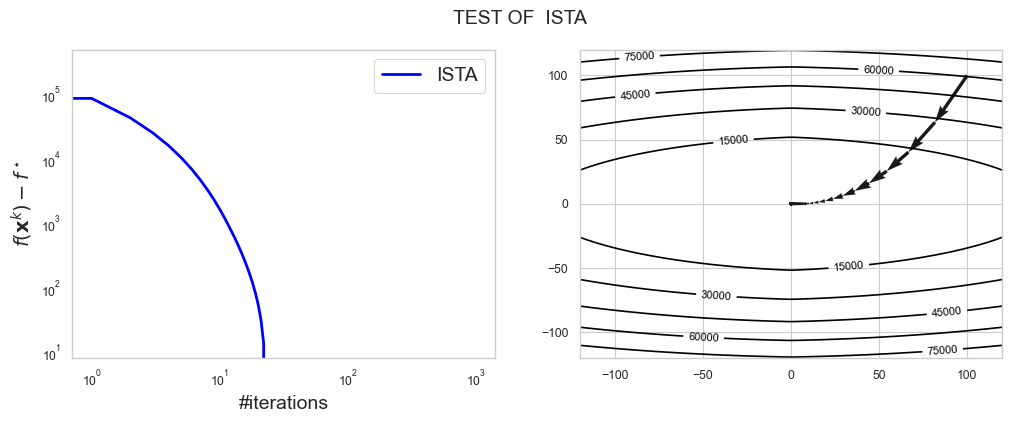

In [45]:
test_composite(ISTA)

#### Question 5  (7 points)

Using the information in Lecture 7 slide 21 fill in the codes of the method $FISTA_{\mu}$.

In [46]:
@dataclass 
class FISTA_state(OptState):
    x_k: Vector
    y_k : Vector
    k : int
    alpha : float
    c_f : float

In [47]:
def FISTA_update(composite_function, state):
    f, g = composite_function
    x_k, y_k, k, alpha, c_f = state

    t = y_k - alpha * f.grad(y_k)
    x_next = l1_prox(alpha, t)
    y_next = x_next + (np.sqrt(c_f) - 1) / (np.sqrt(c_f) + 1) * (x_next - x_k)

    return FISTA_state(x_k = x_next, y_k = y_next, k = k + 1, alpha = alpha, c_f = c_f)

def FISTA_initialize(composite_function, x_zero):
    f, g = composite_function
    alpha = 1.0 / f.lips_grad
    c_f = f.lips_grad / f.strng_cvx
    return FISTA_state(x_k=x_zero, y_k=x_zero, k=1, alpha=alpha, c_f=c_f)

In [48]:
FISTA = OptAlgorithm(name="FISTA", init_state= FISTA_initialize, state_update=FISTA_update)

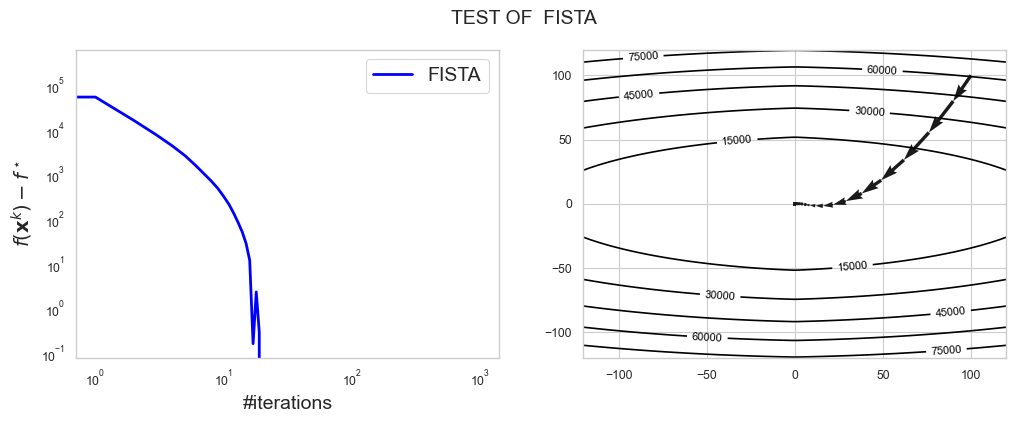

In [49]:
test_composite(FISTA)

#### Question 6  (2 points)

Compare the convergence rates of the three methods and analyze whether the observed results align with their theoretical bounds.

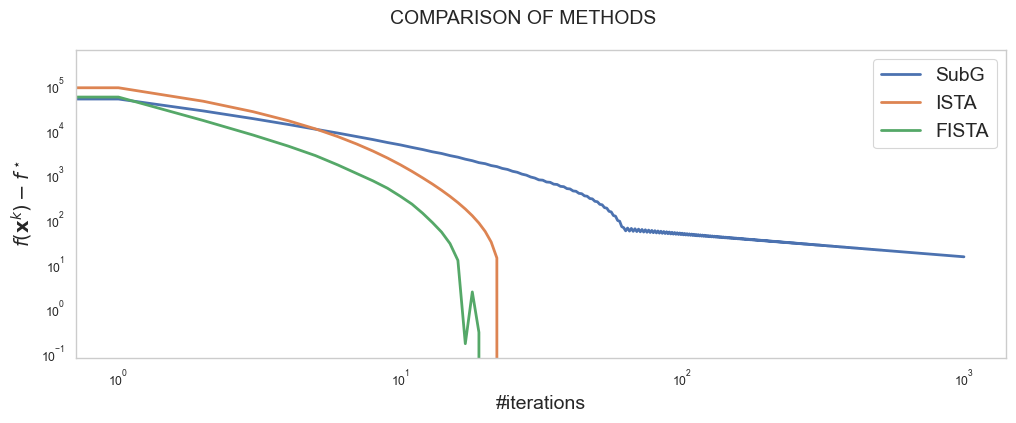

In [50]:
list_of_methods = [SubG, ISTA, FISTA]
compare_composite(list_of_methods)

### Comparison of Convergence Rates

We compare the convergence behavior of three methods for solving the composite optimization problem: the subgradient method (SubG), ISTA (Iterative Soft-Thresholding Algorithm), and FISTA (Fast Iterative Soft-Thresholding Algorithm).

#### Subgradient Method (SubG)
Subgradient methods are applicable to nonsmooth convex functions such as 
$\ell_1$-regularized problems. They use a subgradient direction and typically 
require a diminishing step size $\eta_k \sim 1/\sqrt{k}$. The theoretical 
convergence rate for convex functions is
$$
f(x_k) - f(x^*) = \mathcal{O}\Big(\frac{1}{\sqrt{k}}\Big),
$$
where $x^*$ is an optimal solution. In practice, SubG often exhibits slow 
convergence with zig-zagging iterates, and the objective may decrease 
non-monotonically. Many iterations are required to reach a solution of reasonable accuracy.

#### ISTA (Iterative Soft-Thresholding Algorithm)
ISTA is a proximal gradient method for problems of the form
$$
\min_\alpha f(\alpha) + g(\alpha),
$$
where $f$ is smooth and $g$ is proximable. The update rule is
$$
x_{k+1} = \mathrm{prox}_{\alpha g} \big( x_k - \alpha \nabla f(x_k) \big),
$$
with step size $\eta = 1/L$, where $L$ is the Lipschitz constant of $\nabla f$.  
The theoretical convergence rate for convex $f$ is
$$
F(x_k) - F(x^*) = \mathcal{O}\Big(\frac{1}{k}\Big).
$$
ISTA typically shows monotone and faster convergence than SubG, reaching near-optimal solutions in significantly fewer iterations.

#### FISTA (Fast ISTA)
FISTA accelerates ISTA using Nesterov momentum. Its convergence rate is
$$
F(\alpha_k) - F(\alpha^*) = \mathcal{O}\Big(\frac{1}{k^2}\Big),
$$
which is theoretically faster than both ISTA and SubG. In practice, FISTA exhibits rapid decrease in the objective function, especially in early iterations, though small oscillations may occur due to the momentum term.

#### Analysis
The observed convergence behavior aligns well with theoretical expectations. From the graph we can clearly see that SubG achieves sublinear convergence, whereas ISTA and FISTA both display linear convergence, visible as a sharp "dive" on the logarithmic scale.

SubG is slow because it does not exploit smoothness. ISTA leverages the gradient of $f$ and the proximal operator of $g$, leading to faster and monotone convergence. FISTA further accelerates convergence through momentum, showing rapid decreases in the objective, particularly in the early iterations.  

For composite problems with a smooth term $f$ and a proximable nonsmooth term $g$, proximal gradient methods (ISTA/FISTA) are preferred over subgradient methods due to their superior convergence rates.


# Part 2: Application


We have now implemented multiple methods that can solve composite optimization problems. We will now apply them to an image inpainting problem.


Take a natural image, or better a picture of you, and place it in the same directory as this notebook.

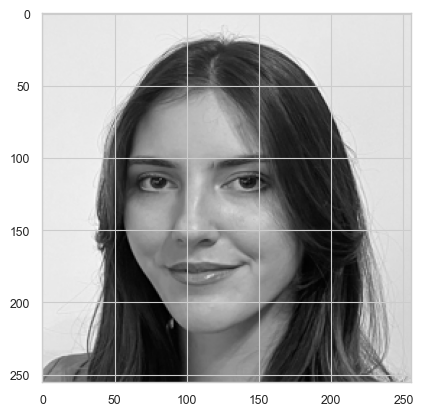

In [51]:
from lib.inpainting import *

image = load("cv_slika-1.jpeg") #FILL IN FILE NAME

With this image in hand, let us subsample it and try to reconstruct the original.

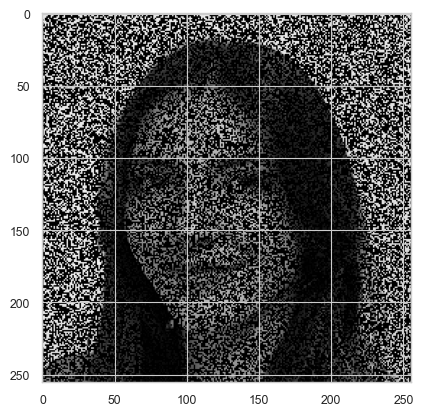

In [52]:
subsampled = show_subsampled(image)

For the rest of the questions, to ensure the function is 
$\mu$-strongly convex, we need to add an $\ell_2$ regularization term to it. As a result, we change the definition of $f_{\ell_1}(\mathbf{\alpha})$ as follows:
$$
    f_{\ell_1}(\mathbf{\alpha}) = \frac{1}{2}\|\mathbf{b} - \mathbf{P}_{\Omega} \mathbf{W}^T\mathbf{\alpha} \|_2^2 + \frac{1}{2}\mu \|\mathbf{\alpha}\|_2^2 
    $$

and the composite function becomes:
 $$
    \min_{\mathbf{\alpha} \in \mathbb{R}^{p}} \underbrace{ \frac{1}{2}\|\mathbf{b} - \mathbf{P}_{\Omega} \mathbf{W}^T\mathbf{\alpha} \|_2^2 + \frac{1}{2}\mu \|\mathbf{\alpha}\|_2^2 }_{f_{\ell_1}(\mathbf{\alpha})} + \underbrace{\lambda_{\ell_1} \|\mathbf{\alpha}\|_1}_{g_{\ell_1}(\mathbf{\alpha})},
    $$

By adding this regularization, we ensure better properties for optimization, making the solution more stable and well-behaved.

In the following cells we will define the optimization problems we need to solve to perform the reconstruction.

- We provide you with a function `P` that acts like the matrix $\mathbf{P}_{\Omega}$. That is, given a vector `x`, it returns a subsampled vector `P(x)` that corresponds to $\mathbf{P}_{\Omega} \mathbf{x}$. We also give you `P_T` which acts like $\mathbf{P}^\top$.
- We provide you with a function `W` and `W_T` that act like the matrix $\mathbf{W}$ and $\mathbf{W^\top}$ respectively. That is, for a vector `x`, `W(x)` and `W_T(x)` return $\mathbf{W}\mathbf{x}$ and $\mathbf{W^\top}\mathbf{x}$ respectively.

__(a)__ (1 point) Using these provided functions, define the observed variable `b` in the cell below.

In [53]:
from lib.inpainting import P, P_T, W, W_T

x = image.reshape(-1) #flattened image

b = P(x)

__(b)__ (1 point) Now define the function `f_l1` as described earlier in the problem text.

In [54]:
mu = 1e-4 # Desired strong convexity of f
def f_l1(alpha):
    return 1/2 * np.linalg.norm(b - P(W_T(alpha)))**2 + mu / 2 * np.linalg.norm(alpha)**2


__(c)__ (1 point) Write the gradient of $f_{\ell_1}(\mathbf{\alpha})$.

In [55]:
def grad_f_l1(alpha):
    return - W(P_T(b - P(W_T(alpha)))) + mu * alpha

__(d)__ (1 points) Find the Lipschitz constant of $\nabla_\mathbf{\alpha} f_{\ell_1}(\mathbf{\alpha})$ analytically and fill it in the cell below. 

We consider the function
$$
f_{\ell_1}(\boldsymbol{\alpha}) = \frac{1}{2} \|\mathbf{b} - \mathbf{P}_\Omega \mathbf{W}^T \boldsymbol{\alpha}\|_2^2 + \frac{1}{2} \mu \|\boldsymbol{\alpha}\|_2^2,
$$
where $\mathbf{b} \in \mathbb{R}^m$, $\mathbf{W} \in \mathbb{R}^{n \times n}$, 
$\mathbf{P}_\Omega \in \mathbb{R}^{m \times n}$ is a projection/subsampling operator, 
and $\mu > 0$ is the $\ell_2$ regularization parameter.

The gradient with respect to $\boldsymbol{\alpha}$ is
$$
\nabla_{\boldsymbol{\alpha}} f_{\ell_1}(\boldsymbol{\alpha}) 
= \mathbf{W} \mathbf{P}_\Omega^\top (\mathbf{P}_\Omega \mathbf{W}^T \boldsymbol{\alpha} - \mathbf{b}) + \mu \boldsymbol{\alpha}
= \mathbf{W} \mathbf{P}_\Omega^\top \mathbf{P}_\Omega \mathbf{W}^T \boldsymbol{\alpha} - \mathbf{W} \mathbf{P}_\Omega^\top \mathbf{b} + \mu \boldsymbol{\alpha}.
$$

This is an affine function of $\boldsymbol{\alpha}$:
$$
\nabla_{\boldsymbol{\alpha}} f_{\ell_1}(\boldsymbol{\alpha}) = (\mathbf{W} \mathbf{P}_\Omega^\top \mathbf{P}_\Omega \mathbf{W}^T + \mu I) \boldsymbol{\alpha} - \mathbf{W}\mathbf{P}_\Omega^\top \mathbf{b}.
$$

#### Definition of Lipschitz constant
The gradient $\nabla f_{\ell_1}$ is $L$-Lipschitz if
$$
\|\nabla f_{\ell_1}(\boldsymbol{\alpha}_1) - \nabla f_{\ell_1}(\boldsymbol{\alpha}_2)\|_2 \le L \|\boldsymbol{\alpha}_1 - \boldsymbol{\alpha}_2\|_2
\quad \forall \, \boldsymbol{\alpha}_1, \boldsymbol{\alpha}_2 \in \mathbb{R}^n.
$$

For an affine gradient of the form $\nabla f(\boldsymbol{\alpha}) = A \boldsymbol{\alpha} + c$, the Lipschitz constant is given by the operator (spectral) norm of the linear part:
$$
L = \| \mathbf{W} \mathbf{P}_\Omega^\top \mathbf{P}_\Omega \mathbf{W}^T + \mu I \|_2 = \lambda_{\max}\big(\mathbf{W} \mathbf{P}_\Omega^\top \mathbf{P}_\Omega \mathbf{W}^T + \mu I\big),
$$
where $\lambda_{\max}(\cdot)$ denotes the largest eigenvalue.

Assume that:
- $\mathbf{W}$ is orthogonal: $\mathbf{W}^T \mathbf{W} = I$,
- $\mathbf{P}_\Omega^\top \mathbf{P}_\Omega$ is a diagonal projection matrix with spectral norm less or equal to $1$.


Using the fact that the spectral norm is invariant under orthogonal similarity transforms:
$$
\|\mathbf{W} \mathbf{P}_\Omega^\top \mathbf{P}_\Omega \mathbf{W}^T\|_2 = \|\mathbf{P}_\Omega^\top \mathbf{P}_\Omega\|_2 \le 1.
$$

Hence, the Lipschitz constant simplifies to
$$
L = \| \mathbf{W} \mathbf{P}_\Omega^\top \mathbf{P}_\Omega \mathbf{W}^T + \mu I \|_2
= \| \mathbf{W} \mathbf{P}_\Omega^\top \mathbf{P}_\Omega \mathbf{W}^T \|_2 + \|\mu I\|_2
= \| \le 1 + \mu
\quad \Longrightarrow \quad
L = 1 + \mu.
$$

This value can be used as the step size parameter for gradient-based or proximal-gradient algorithms to ensure convergence.


In [56]:
lips_grad_f_l1 = 1 + mu

We have all the necessary ingredients to define the smooth part of our composite objective:

In [57]:
f_l1 = Function(f = f_l1, grad=grad_f_l1, lips_grad = lips_grad_f_l1, strng_cvx=mu)

For the non-smooth term, we define a regularizer built around the `l1` function that re-uses the `l1_prox` function you implemented earlier:

In [58]:
l1 = Function(f = lambda x: np.sum(np.abs(x), axis=0), prox=l1_prox)

g_l1 = Regularizer(l1)

In [59]:
composite_objective = CompositeFunction(f=f_l1, g=g_l1)

With the objective defined, we provide you with a function with the following signature:
```python
solve_composite(method: OptAlgorithm, composite_objective: CompositeFunction, lmda: float, max_iterations: int) -> Vector
```

In other words, the function takes an optimization algorithm `method`, a CompositeFunction `composite_objective`, a regularization parameter `lmda` and a number of iterations `max_iterations` and returns a vector which is the last iterate given by the `method`.



In [60]:
from lib.inpainting import solve_composite

__(e)__ (5 points) Using `solve_composite` reconstruct the subsampled image. Recall that the composite problem solves for $\mathbf{\alpha}$ so you need to convert the output back to an image and visualize it.

Select a reasonable value for `lmda` or (BONUS) using the function `solve_composite` and the `PSNR` metric, find the best value for `lmda`.

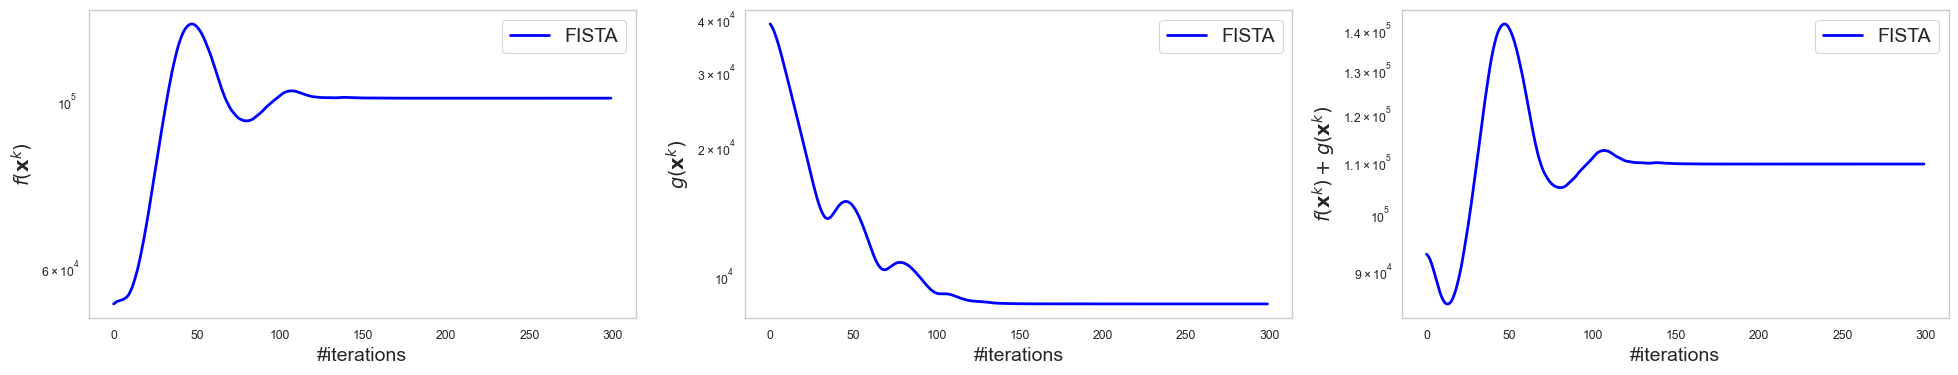

In [ ]:
lmda = 0.01
max_iterations = 300

output = solve_composite(FISTA, composite_objective, lmda=lmda, max_iterations=max_iterations)
flat_image_out = W_T(output)
image_out = flat_image_out.reshape(image.shape)


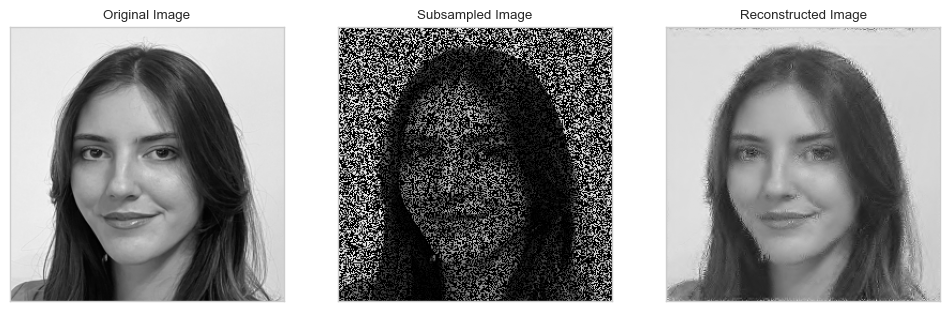

In [62]:
show(true = image, subsampled=subsampled, estimated=image_out)